# Practice 4.
## Objectives:
1. Do a simple Linear classifier
2. Deal with *colinearity*
3. Understand how the logistic regression works
4. Learn to clean up databases.

Aplication:
Data basse: Data set from the UCI Machine Learning Repository (http://archive.ics.uci.edu/ml)

Bank marketing prediction Data Set: http://archive.ics.uci.edu/ml/datasets/Bank+Marketing
Predict **has the client subscribed a term deposit? (binary: 'yes','no')**.

In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay



In [2]:
File = "bank-full.xls"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')

Filename with path: 
 c:\mlearn-lab\FourthPractice\Data\bank-full.xls


% Note in case of error, check if you have the library xlrd installed, and if not, install it with the following command:
pip install xlrd>=2.0.1

In [3]:


Data = pd.read_excel(Filename)
Data.head().T

,0,1,2,3,4
age,58,44,33,47,33
job,management,technician,entrepreneur,blue-collar,unknown
marital,married,single,married,married,single
education,tertiary,secondary,secondary,unknown,unknown
default,no,no,no,no,no
balance,2143,29,2,1506,1
housing,yes,yes,yes,yes,no
loan,no,no,yes,no,no
contact,unknown,unknown,unknown,unknown,unknown
day,5,5,5,5,5


### First take a glimpse of the numerical data

In [4]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


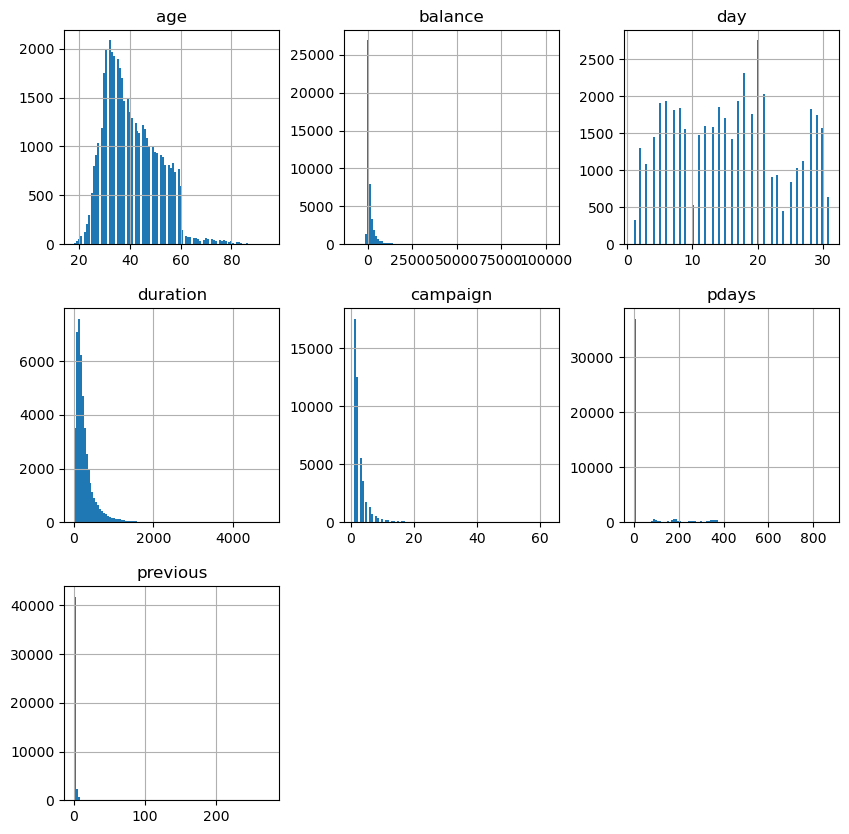

In [5]:
ax =Data.hist(figsize= (10,10),bins = 100)

Lets see if the follow up of the client "pdays" changes something


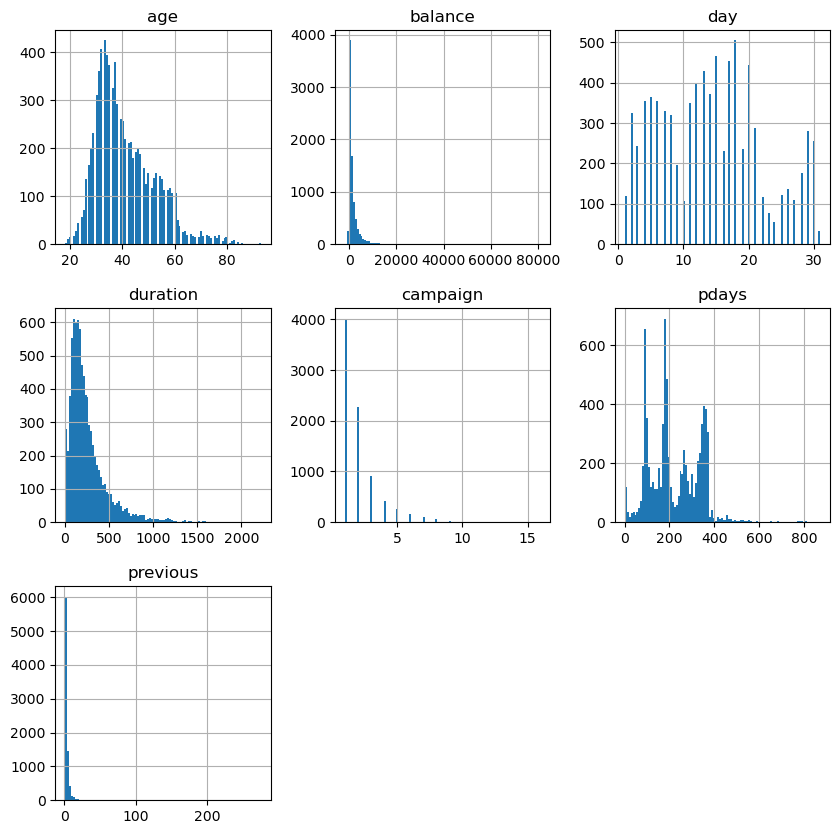

In [6]:
print('Lets see if the follow up of the client "pdays" changes something')
ax = Data[Data['pdays']>0].hist(figsize= (10,10),bins = 100)

In [7]:
Data.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

## Clean the categorial features
### First we select the columns that are string (objects)

In [8]:
Data.select_dtypes(include=['object']).T

,0,1,2,3,4,5,6,7,8,9,...,45201,45202,45203,45204,45205,45206,45207,45208,45209,45210
job,management,technician,entrepreneur,blue-collar,unknown,management,management,entrepreneur,retired,technician,...,management,admin.,student,retired,technician,technician,retired,retired,blue-collar,entrepreneur
marital,married,single,married,married,single,married,single,divorced,married,single,...,married,single,single,married,single,married,divorced,married,married,married
education,tertiary,secondary,secondary,unknown,unknown,tertiary,tertiary,tertiary,primary,secondary,...,tertiary,secondary,tertiary,secondary,secondary,tertiary,primary,secondary,secondary,secondary
default,no,no,no,no,no,no,no,yes,no,no,...,no,no,no,no,no,no,no,no,no,no
housing,yes,yes,yes,yes,no,yes,yes,yes,yes,yes,...,no,no,no,no,no,no,no,no,no,no
loan,no,no,yes,no,no,no,yes,no,no,no,...,no,no,no,no,yes,no,no,no,no,no
contact,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,...,cellular,cellular,cellular,cellular,cellular,cellular,cellular,cellular,telephone,cellular
month,may,may,may,may,may,may,may,may,may,may,...,nov,nov,nov,nov,nov,nov,nov,nov,nov,nov
poutcome,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,...,success,unknown,unknown,failure,unknown,unknown,unknown,success,unknown,other
y,no,no,no,no,no,no,no,no,no,no,...,yes,yes,yes,yes,yes,yes,yes,yes,no,no


In [9]:
StringColumns = Data.select_dtypes(include=['object']).columns.values
print(f'Columns that need a numerical coding: {StringColumns}')

Columns that need a numerical coding: ['job' 'marital' 'education' 'default' 'housing' 'loan' 'contact' 'month'
 'poutcome' 'y']


## Next we correct some of the features
###  Note the 'unique' method for DataFrames

In [10]:
TypesOfJobs = list(Data['job'].unique())
print(f'Types of Jobs:{TypesOfJobs}')
print()
print(f' Number of categories: {len(TypesOfJobs)}')

Types of Jobs:['management', 'technician', 'entrepreneur', 'blue-collar', 'unknown', 'retired', 'admin.', 'services', 'self-employed', 'unemployed', 'housemaid', 'student']

 Number of categories: 12


### As there is a relationship between salary and profesion we will introduce an adhoc code.

1.   Remember the use of the 'map' instruction.
2.   If you are interested in big data look for 'map-reduce'.

In [11]:
CodingJob = dict()
CodingJob['management'] = 12
CodingJob['technician'] = 10
CodingJob['entrepreneur'] = 11
CodingJob['blue-collar'] = 9
CodingJob['unknown'] = 5
CodingJob['retired'] = 6
CodingJob['admin.'] = 7
CodingJob['services'] = 8
CodingJob['self-employed'] = 1
CodingJob['unemployed'] = 4
CodingJob['housemaid'] = 3
CodingJob['student'] = 2
Data['job'] = Data['job'].map(CodingJob)

In [12]:
Default = dict()
Default['no'] = -1
Default['yes'] = +1
Data['default'] = Data['default'].map(Default)

###  We code the output 'y'

Remember we have a logistic regression as classifier:

$y = \frac{1}{1+e^{\beta^T X}}\longrightarrow$    Range: (0,1)

In [13]:
y = dict()
y['no'] = 0.
y['yes'] = +1.
Data['y'] = Data['y'].map(y)

In [14]:
MeanValue = Data['y'].mean()*100.
print(f' The proportion of yes: {MeanValue:2.2f} %')
print('Note that the classes are unbalanced. In theory we will see how to deal with this phenomenon')

 The proportion of yes: 11.70 %
Note that the classes are unbalanced. In theory we will see how to deal with this phenomenon



## Homework: <font color='red'> Do the same procedure for the rest of the categorical variables.</font>

## Homework: <font color='red'> Do an exploratory data analysis in order to understand the database.</font>  

###  We delete the columns that have not been used

In [15]:
Data = Data.select_dtypes(exclude=['object'])

In [16]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
job,45211.0,8.63,2.85,1.0,7.0,9.0,10.0,12.0
default,45211.0,-0.96,0.27,-1.0,-1.0,-1.0,-1.0,1.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0
y,45211.0,0.12,0.32,0.0,0.0,0.0,0.0,1.0


### Scatter plot with a color per class

In [17]:
if False:
    ax = pd.plotting.scatter_matrix(Data,c =Data['y'], figsize = (10,10))

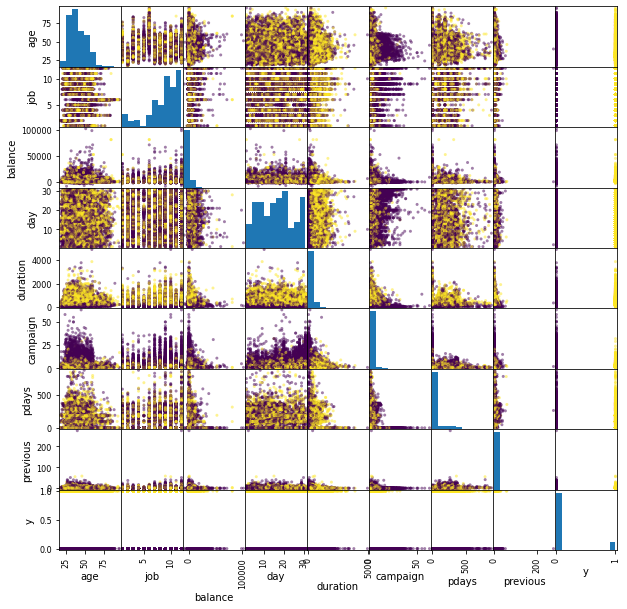

## We do the partition in training and testing data.

### We will use a helper function

In [18]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB

In [19]:
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)

In [20]:
print('Next we correct the data types')
TrainDB.dtypes

Next we correct the data types


age           int64
job           int64
default       int64
balance       int64
day           int64
duration      int64
campaign      int64
pdays         int64
previous      int64
y           float64
dtype: object

In [21]:
TrainDB = TrainDB.astype('float')
TestDB = TestDB.astype('float')

### Lets try a logistic classifier

In [22]:
y = TrainDB['y']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'y']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['age', 'job', 'default', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
__________________________________________________


In [23]:
logreg = LogisticRegression(solver='newton-cg',penalty = 'l2',C=10,max_iter = 1000,fit_intercept = True)
logreg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cg'
,max_iter,1000
,multi_class,'deprecated'



## Homework: <font color='red'>Explain a strategy of classification by reading the coefficients, which is the relationship between the meaning of each variable (and statistical distribution), its sign and the absolute value</font>


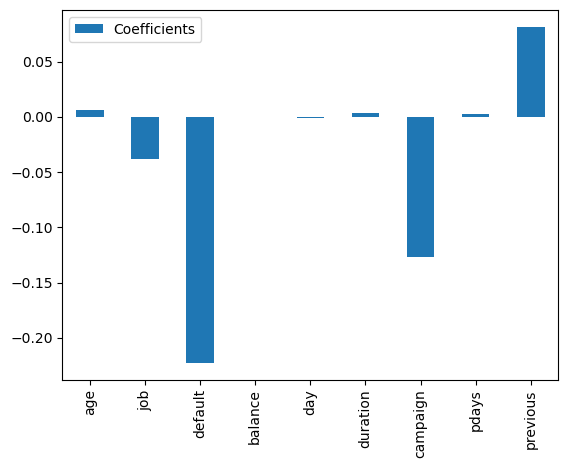

In [24]:
Features = X.columns
df = pd.DataFrame(data = logreg.coef_.T, index = Features, columns = ['Coefficients'] )
ax = df.plot.bar()

In [25]:
print('WHY. Hint')
Data.describe().T

WHY. Hint


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211.0,8.631771,2.847568,1.0,7.0,9.0,10.0,12.0
default,45211.0,-0.963947,0.266098,-1.0,-1.0,-1.0,-1.0,1.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0
y,45211.0,0.116985,0.321406,0.0,0.0,0.0,0.0,1.0


###  Method sensitive to the scale of the dataa
####  Further in the course we will see a better way of solving this problem (hint: look at from sklearn.preprocessing import StandardScaler)

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.000000,33.000000,39.000000,48.000000,95.000000
job,45211.0,8.631771,2.847568,1.000000,7.000000,9.000000,10.000000,12.000000
default,45211.0,-0.963947,0.266098,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
balance,45211.0,1362.272058,3044.765829,-8019.000000,72.000000,448.000000,1428.000000,102127.000000
day,45211.0,15.806419,8.322476,1.000000,8.000000,16.000000,21.000000,31.000000
duration,45211.0,5.171812,0.921822,0.000000,4.644391,5.198497,5.768321,8.500861
campaign,45211.0,2.763841,3.098021,1.000000,1.000000,2.000000,3.000000,63.000000
pdays,45211.0,40.197828,100.128746,-1.000000,-1.000000,-1.000000,-1.000000,871.000000
previous,45211.0,0.580323,2.303441,0.000000,0.000000,0.000000,0.000000,275.000000
y,45211.0,0.116985,0.321406,0.000000,0.000000,0.000000,0.000000,1.000000


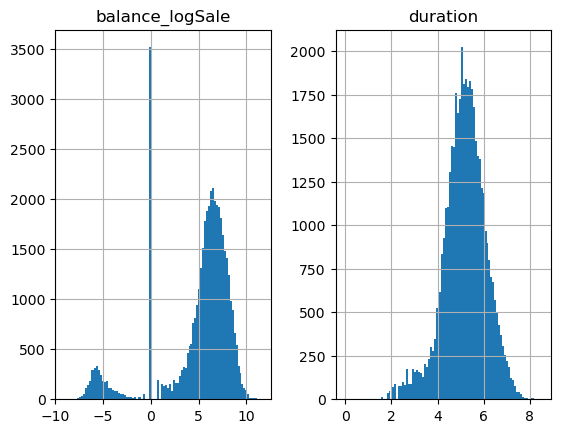

In [26]:
Data['balance_logSale'] = np.log(np.abs(Data['balance'])+1)*np.sign(Data['balance'])
Data['duration'] = np.log(Data['duration']+1)
Data[['balance_logSale','duration']].hist(bins = 100)
Data.describe().T

##  Now we have two gaussians !!!!

### We update the database

In [27]:
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)
TrainDB = TrainDB.astype('float')
TestDB = TestDB.astype('float')
y = TrainDB['y']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'y']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['age', 'job', 'default', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'balance_logSale']
__________________________________________________


In [28]:
logreg = LogisticRegression(solver='newton-cg',penalty = 'l2',C=1,max_iter = 1000,fit_intercept = True)
logreg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cg'
,max_iter,1000
,multi_class,'deprecated'


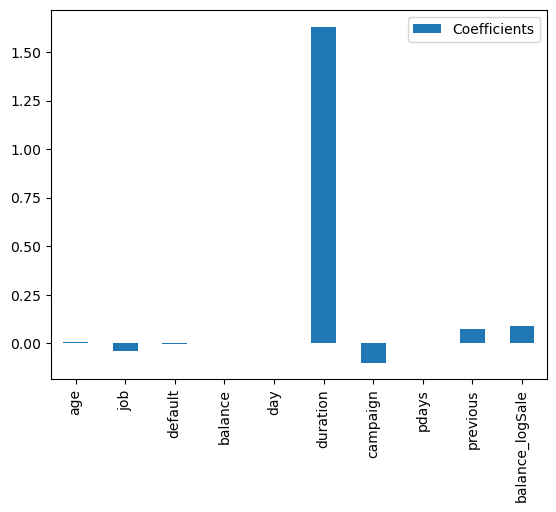

In [29]:
Features = X.columns
df = pd.DataFrame(data = logreg.coef_.T, index = Features, columns = ['Coefficients'] )
ax = df.plot.bar()


## Homework: <font color='red'>Explain what has happened. Why irrelevant variables in one scale are important in another scale</font>

## Performance index: Accuracy score

**Definition:**
$\texttt{accuracy}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples}-1} 1(\hat{y}_i = y_i)$

**Note:** There are more performance indices. We will see them further in the course.

Accuracy (train)  88.9% 
[[29490   490]
 [ 3277   651]]


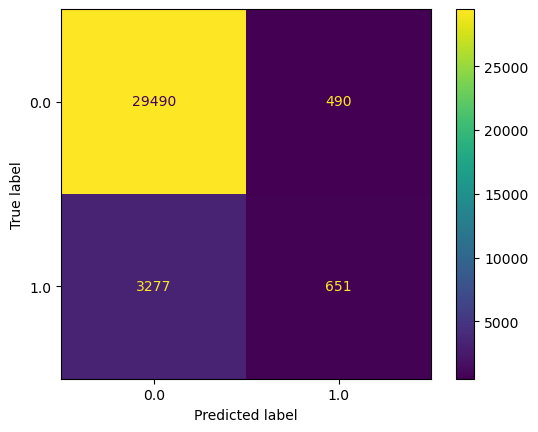

In [30]:

y_hat = logreg.predict(X)
accuracy = accuracy_score(y, y_hat)
print("Accuracy (train)  %0.1f%% " % ( accuracy * 100))
print(confusion_matrix(y, y_hat))
ConfusionMatrixDisplay.from_estimator(logreg, X, y)
plt.show()


## Homework: <font color='red'>Compute the accuracy in the test database</font>

## Homework: <font color='red'>Compute the performance in the initial model with the variables in linear scale</font>

## Homework: <font color='red'>Do some feature engineering for improving the performance. Try to justify the feature engineering from your understanding of the problem, i.e. common sense and probability distributions</font>


## Cross-validation to find the optimal C parameter

The C parameter in Logistic Regression is the inverse of the regularization strength. We will use cross-validation to find the optimal C value that maximizes accuracy.


In [31]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import KFold

# Define the range of C values to test
C_values = np.logspace(-3, 3, 50)

# Create LogisticRegressionCV to find optimal C using cross-validation
logreg_cv = LogisticRegressionCV(Cs=C_values, cv=5, solver='newton-cg', 
                                   penalty='l2', max_iter=1000, fit_intercept=True, 
                                   scoring='accuracy')

# Prepare fresh training data
TrainDB_cv, TestDB_cv = PartitionOfDatabase(Data, Fraction=0.75)
TrainDB_cv = TrainDB_cv.astype('float')
TestDB_cv = TestDB_cv.astype('float')
y_train = TrainDB_cv['y']
X_train = TrainDB_cv[InputFeatures]
y_test = TestDB_cv['y']
X_test = TestDB_cv[InputFeatures]

# Fit the model with cross-validation
logreg_cv.fit(X_train, y_train)

# Get the optimal C
optimal_C = logreg_cv.C_[0]
print(f"Optimal C parameter found by cross-validation: {optimal_C:.4f}")
print(f"Cross-validation scores: {logreg_cv.scores_[1].mean():.4f} (+/- {logreg_cv.scores_[1].std():.4f})")


Optimal C parameter found by cross-validation: 0.2812
Cross-validation scores: 0.8873 (+/- 0.0016)


### Performance on Training Database


Accuracy (train)  88.8% 
[[29418   512]
 [ 3301   677]]


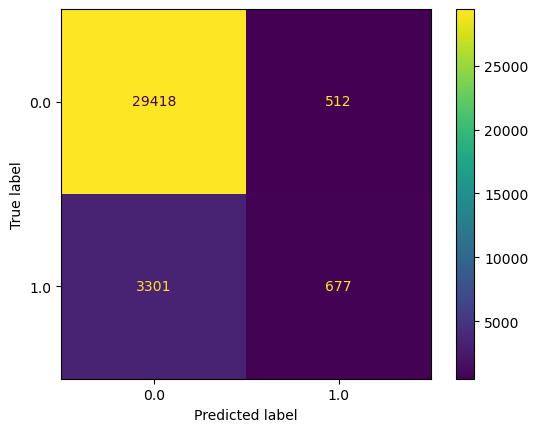

In [32]:
y_hat_train = logreg_cv.predict(X_train)
accuracy_train = accuracy_score(y_train, y_hat_train)
print("Accuracy (train)  %0.1f%% " % (accuracy_train * 100))
print(confusion_matrix(y_train, y_hat_train))
ConfusionMatrixDisplay.from_estimator(logreg_cv, X_train, y_train)
plt.show()


### Performance on Test Database


Accuracy (test)  88.9% 
[[9828  164]
 [1094  217]]


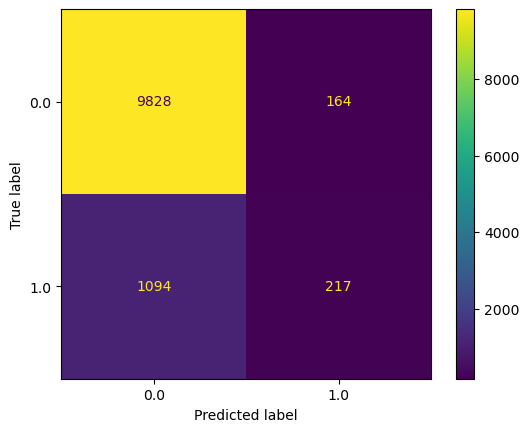

In [33]:
y_hat_test = logreg_cv.predict(X_test)
accuracy_test = accuracy_score(y_test, y_hat_test)
print("Accuracy (test)  %0.1f%% " % (accuracy_test * 100))
print(confusion_matrix(y_test, y_hat_test))
ConfusionMatrixDisplay.from_estimator(logreg_cv, X_test, y_test)
plt.show()


 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.


# Appendix: Description of the database

### For more information, read [Moro et al., 2011].

   Input variables:
   ### bank client data:
   1 - age (numeric)
   
   2 - job : type of job (categorical: 
   "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
                                       
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   
   5 - default: has credit in default? (binary: "yes","no")
   
   6 - balance: average yearly balance, in euros (numeric) 
   
   7 - housing: has housing loan? (binary: "yes","no")
   
   8 - loan: has personal loan? (binary: "yes","no")
   
   ### related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")
   
  10 - day: last contact day of the month (numeric)
  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  
  12 - duration: last contact duration, in seconds (numeric)
  
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")
  

  ## Output variable (desired target):
  
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")